In [16]:
from dataclasses import dataclass
from typing import List

import numpy as np
import pandas as pd
import yfinance as yf
import sys
import os
import importlib
import matplotlib.pyplot as plt

# Module 1 — Market Data Import and Hypothetical Portfolio Setup

The first step of this project is to build a clean market data layer. In a real bank market risk system, reliable market data is the foundation for all downstream pricing, PnL, volatility, VaR, stress testing, derivatives pricing, and risk reporting calculations.

In this project, I used Yahoo Finance data through the `yfinance` Python package to retrieve historical adjusted market prices for a group of liquid US-listed ETFs. The selected assets are:

- SPY: S&P 500 ETF
- QQQ: Nasdaq 100 ETF
- GLD: Gold ETF
- BND: Bond ETF
- VTI: Total US Market ETF

These assets were chosen to represent a simplified multi-asset portfolio with exposure to equities, technology, gold, bonds, and the broad US market.

The portfolio used in this project is a **hypothetical portfolio**. It is not based on a real trading account. I manually assigned assumed quantities to each ETF so that the pricing engine and risk engine would have a portfolio to value and analyze.

The assumed holdings are:

- SPY: 100 shares
- QQQ: 80 shares
- GLD: 50 shares
- BND: 120 shares
- VTI: 90 shares

The purpose of creating this hypothetical portfolio is to demonstrate how a market risk system takes market prices and position data as inputs, then produces portfolio valuation, PnL, returns, volatility, VaR, stress testing results, and risk reports.

The market data workflow includes:

1. Downloading historical adjusted price data.
2. Cleaning missing values using forward fill and dropping any remaining missing observations.
3. Calculating daily log returns.
4. Creating a hypothetical portfolio table with tickers, assumed quantities, latest prices, and market values.
5. Saving the cleaned data and portfolio data into CSV files for later modules.

The three core output files from Module 1 are:

`prices.csv` contains the historical adjusted price data.

`returns.csv` contains the daily log returns calculated from the adjusted prices.

`portfolio.csv` contains the hypothetical portfolio holdings, including ticker, quantity, latest price, and market value.

These files are saved permanently in Google Drive under the project folder:

`/content/drive/MyDrive/market_risk_project/data`

Saving the files to Google Drive makes the project reusable across different Colab notebooks. Later modules can load these saved files directly instead of downloading the data again.

In [22]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
!ls /content/drive/MyDrive/market_risk_project/src

pricing_engine.py  __pycache__


In [25]:
PROJECT_DIR = "/content/drive/MyDrive/market_risk_project"
SRC_DIR = f"{PROJECT_DIR}/src"
DATA_DIR = f"{PROJECT_DIR}/data"

print("SRC_DIR:", SRC_DIR)
print("Does SRC_DIR exist?", os.path.exists(SRC_DIR))
print("Files in SRC_DIR:", os.listdir(SRC_DIR))

# Put the src folder at the front of Python's search path
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Clear import cache
importlib.invalidate_caches()



SRC_DIR: /content/drive/MyDrive/market_risk_project/src
Does SRC_DIR exist? True
Files in SRC_DIR: ['pricing_engine.py', '__pycache__']


In [27]:
prices = pd.read_csv(f"{DATA_DIR}/prices.csv", index_col=0, parse_dates=True)
portfolio = pd.read_csv(f"{DATA_DIR}/portfolio.csv")
returns = pd.read_csv(f"{DATA_DIR}/returns.csv")

**Module 2 — Portfolio Pricing Engine**

This module acts as a simplified pricing engine. It takes market prices and portfolio holdings as inputs, then calculates

daily position values,

total portfolio value,

daily PnL,

portfolio returns,

cumulative return,

and current portfolio weights.

I created a separate Colab notebook to demonstrate the pricing engine, instead of rewriting all class definitions directly inside the notebook, I saved the pricing engine as a separate Python file:

`pricing_engine.py`

This file is stored permanently in Google Drive under:

`/content/drive/MyDrive/market_risk_project/src`

The purpose of separating the pricing engine into its own `.py` file is to make the project more modular.

In [12]:
from pricing_engine import PortfolioPricingEngine

print("Import successful.")
print(PortfolioPricingEngine)

pricing_engine = PortfolioPricingEngine(prices, portfolio)
pricing_results = pricing_engine.run()

print(f"Current Portfolio Market Value: ${pricing_results['current_market_value']:,.2f}")
display(pricing_results["weights"])

Current Portfolio Market Value: $194,091.52


,Ticker,Quantity,Latest Price,Market Value,Weight
0,SPY,100,746.770020,74677.001953,0.384751
1,QQQ,80,736.400024,58912.001953,0.303527
2,GLD,50,368.380005,18419.000244,0.094899
3,BND,120,73.166000,8779.920044,0.045236
4,VTI,90,370.040009,33303.600769,0.171587


In [21]:

position_values = pricing_results["position_values"]
portfolio_value = pricing_results["portfolio_value"]
current_market_value = pricing_results["current_market_value"]
daily_pnl = pricing_results["daily_pnl"]
portfolio_returns = pricing_results["portfolio_returns"]
cumulative_return = pricing_results["cumulative_return"]
weights = pricing_results["weights"]

print(f"Current Portfolio Market Value: ${current_market_value:,.2f}")

print("\nCurrent Portfolio Weights:")
display(weights)


Current Portfolio Market Value: $194,091.52

Current Portfolio Weights:


,Ticker,Quantity,Latest Price,Market Value,Weight
0,SPY,100,746.770020,74677.001953,0.384751
1,QQQ,80,736.400024,58912.001953,0.303527
2,GLD,50,368.380005,18419.000244,0.094899
3,BND,120,73.166000,8779.920044,0.045236
4,VTI,90,370.040009,33303.600769,0.171587


In [15]:

position_values.to_csv(f"{DATA_DIR}/position_values.csv")
portfolio_value.to_csv(f"{DATA_DIR}/portfolio_value.csv", header=["Portfolio Value"])
daily_pnl.to_csv(f"{DATA_DIR}/daily_pnl.csv", header=["Daily PnL"])
portfolio_returns.to_csv(f"{DATA_DIR}/portfolio_returns.csv", header=["Portfolio Return"])
cumulative_return.to_csv(f"{DATA_DIR}/cumulative_return.csv", header=["Cumulative Return"])
weights.to_csv(f"{DATA_DIR}/portfolio_weights.csv", index=False)

print("Module 2 outputs saved to Google Drive.")

Module 2 outputs saved to Google Drive.


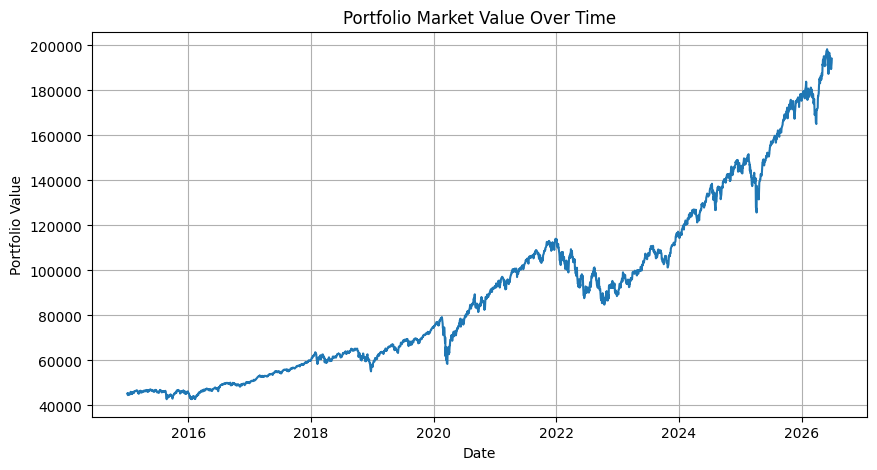

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(portfolio_value)
plt.title("Portfolio Market Value Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

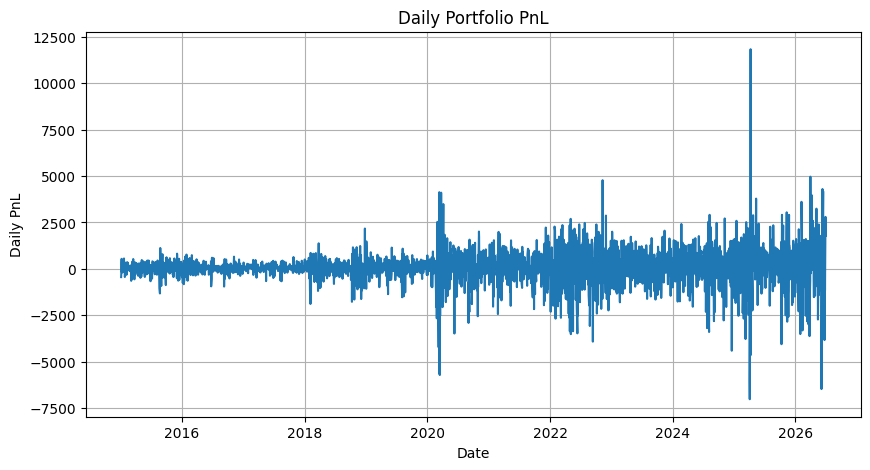

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(daily_pnl)
plt.title("Daily Portfolio PnL")
plt.xlabel("Date")
plt.ylabel("Daily PnL")
plt.grid(True)
plt.show()

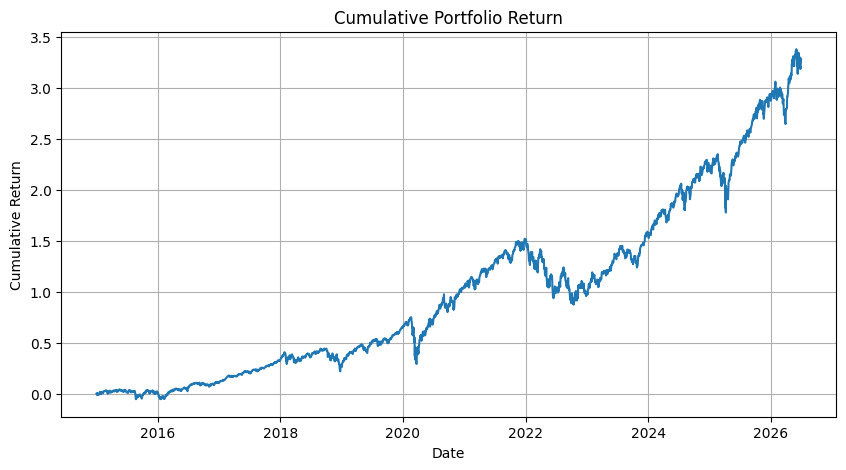

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(cumulative_return)
plt.title("Cumulative Portfolio Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

# Module 3 — Market Risk Engine

This module calculates the core market risk metrics of the portfolio.

The inputs are the cleaned asset returns from Module 1 and the portfolio-level returns and weights from Module 2. The market risk engine calculates asset-level volatility, portfolio volatility, correlation matrix, covariance matrix, rolling volatility, and return distribution statistics.

The key output is the annualized portfolio volatility, which provides a summary measure of the portfolio's overall market risk.

In [29]:
PROJECT_DIR = "/content/drive/MyDrive/market_risk_project"
SRC_DIR = f"{PROJECT_DIR}/src"
DATA_DIR = f"{PROJECT_DIR}/data"

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

importlib.invalidate_caches()

from risk_engine import MarketRiskEngine

print("MarketRiskEngine imported successfully.")

MarketRiskEngine imported successfully.


In [30]:
returns = pd.read_csv(
    f"{DATA_DIR}/returns.csv",
    index_col=0,
    parse_dates=True
)

portfolio_returns = pd.read_csv(
    f"{DATA_DIR}/portfolio_returns.csv",
    index_col=0,
    parse_dates=True
)

weights = pd.read_csv(
    f"{DATA_DIR}/portfolio_weights.csv"
)

print("Asset Returns:")
display(returns.tail())

print("Portfolio Returns:")
display(portfolio_returns.tail())

print("Portfolio Weights:")
display(weights)

Asset Returns:


,BND,GLD,QQQ,SPY,VTI
Date,,,,,
2026-06-24,0.004497,-0.030679,-0.004255,-0.000464,-0.000138
2026-06-25,0.000680,0.009628,0.008073,0.001445,0.000907
2026-06-26,0.000951,0.011224,-0.013859,-0.007258,-0.001975
2026-06-29,0.000543,-0.013608,0.024550,0.016341,0.013437
2026-06-30,-0.004078,-0.000543,0.016872,0.007757,0.007922


Portfolio Returns:


,Portfolio Return
Date,
2026-06-24,-0.004255
2026-06-25,0.004104
2026-06-26,-0.006122
2026-06-29,0.014770
2026-06-30,0.009253


Portfolio Weights:


,Ticker,Quantity,Latest Price,Market Value,Weight
0,SPY,100,746.770020,74677.001953,0.384751
1,QQQ,80,736.400024,58912.001953,0.303527
2,GLD,50,368.380005,18419.000244,0.094899
3,BND,120,73.166000,8779.920044,0.045236
4,VTI,90,370.040009,33303.600769,0.171587


In [31]:
risk_engine = MarketRiskEngine(
    asset_returns=returns,
    portfolio_returns=portfolio_returns,
    weights=weights
)

risk_results = risk_engine.run()

In [33]:
# extracting result from M3
asset_volatility = risk_results["asset_volatility"]
correlation_matrix = risk_results["correlation_matrix"]
covariance_matrix = risk_results["covariance_matrix"]
portfolio_volatility = risk_results["portfolio_volatility"]
rolling_volatility = risk_results["rolling_volatility"]
return_stats = risk_results["return_stats"]

print("\nPortfolio Return Distribution Statistics:")
display(return_stats)


Portfolio Return Distribution Statistics:


,Value
Mean Daily Return,0.000550
Daily Volatility,0.009554
Annualized Return,0.138612
Annualized Volatility,0.151659
Minimum Daily Return,-0.086728
Maximum Daily Return,0.094125
Skewness,-0.263362
Kurtosis,12.135628


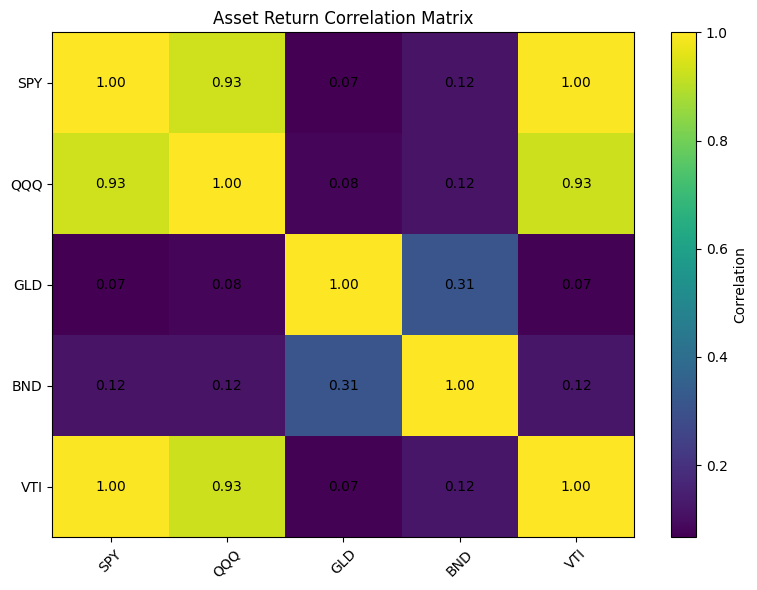

In [34]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    ticks=range(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    ticks=range(len(correlation_matrix.index)),
    labels=correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Asset Return Correlation Matrix")
plt.tight_layout()
plt.show()

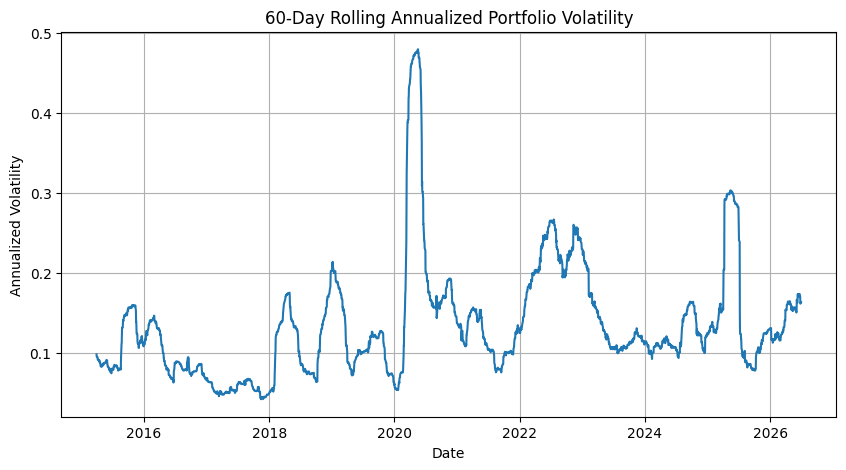

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(rolling_volatility)
plt.title("60-Day Rolling Annualized Portfolio Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.grid(True)
plt.show()

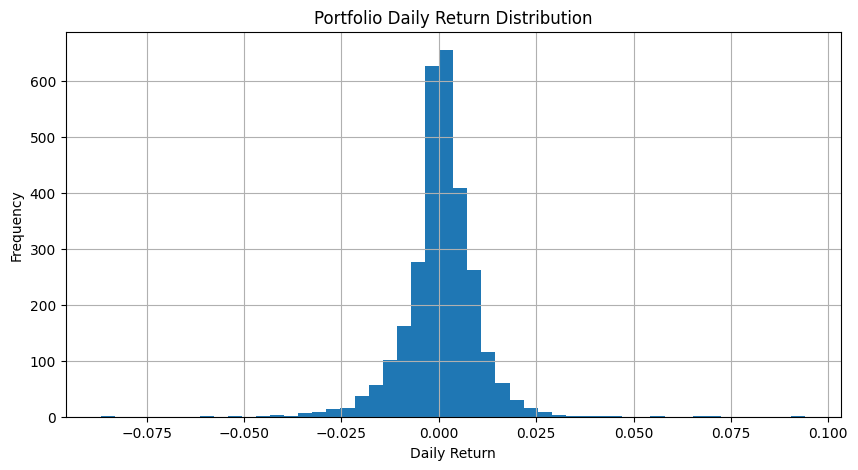

In [36]:
portfolio_return_series = portfolio_returns.iloc[:, 0]

plt.figure(figsize=(10, 5))
plt.hist(portfolio_return_series, bins=50)
plt.title("Portfolio Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()